# Image Compression via Truncated SVD

**Project 5 — Low-Rank Approximation**
*Numerical Linear Algebra, MSc MMCS, University of Luxembourg*

Authors: Abhishek Jha, Favour Gilbert Mmesoma, Muhammad Shehaan Butt

---

We treat a grayscale image as a matrix $A \in \mathbb{R}^{m\times n}$ of pixel intensities, compute its SVD
$$A = U \Sigma V^\top,$$
and study the rank-$k$ approximation
$$A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^\top.$$

By **Eckart–Young–Mirsky**, $A_k$ minimises both $\|A-B\|_F$ and $\|A-B\|_2$ over all rank-$k$ matrices $B$.


In [1]:
!python -m pip install scikit-image

Image: Astronaut (skimage, grayscale), shape = (512, 512), dtype = float64


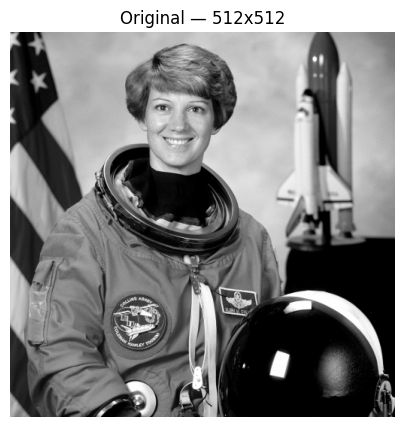

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd, norm

# Load a smooth portrait image -- SVD compression works best on smooth content
try:
    from skimage import data, color
    img = (color.rgb2gray(data.astronaut()) * 255).astype(float)   # 512x512 grayscale portrait
    img_name = "Astronaut (skimage, grayscale)"
except ImportError:
    from scipy.datasets import face
    img = face(gray=True).astype(float)                             # 768x1024 grayscale
    img_name = "Face (scipy)"

print(f"Image: {img_name}, shape = {img.shape}, dtype = {img.dtype}")

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.title(f"Original — {img.shape[0]}x{img.shape[1]}")
plt.axis('off')
plt.show()


## Compute the SVD

In [3]:
U, S, Vt = svd(img, full_matrices=False)
print(f"U:  {U.shape}")
print(f"S:  {S.shape}   (singular values)")
print(f"Vt: {Vt.shape}")
print(f"Largest sigma: {S[0]:.2f}")
print(f"Smallest nonzero sigma: {S[S>1e-10][-1]:.2e}")


U:  (512, 512)
S:  (512,)   (singular values)
Vt: (512, 512)
Largest sigma: 61520.67
Smallest nonzero sigma: 1.27e-01


## Singular Value Spectrum

Decay rate determines how aggressively we can truncate.

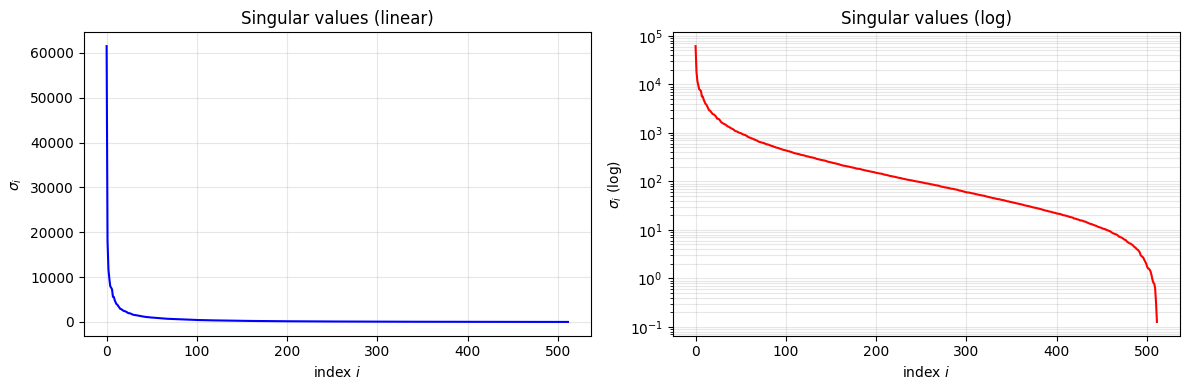

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(S, 'b-', linewidth=1.5)
axes[0].set_xlabel('index $i$')
axes[0].set_ylabel('$\\sigma_i$')
axes[0].set_title('Singular values (linear)')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(S, 'r-', linewidth=1.5)
axes[1].set_xlabel('index $i$')
axes[1].set_ylabel('$\\sigma_i$ (log)')
axes[1].set_title('Singular values (log)')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()


## Rank-$k$ Reconstruction

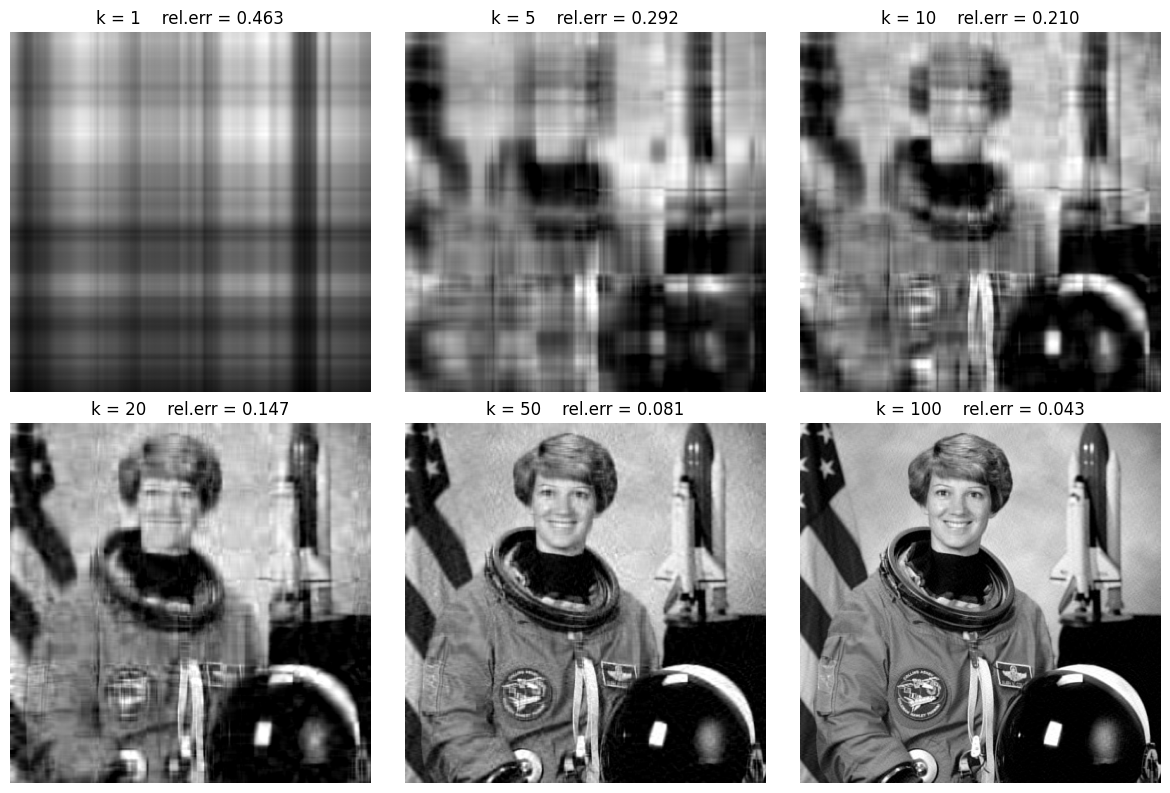

In [5]:
def low_rank_approx(U, S, Vt, k):
    "Return rank-k approximation A_k = U[:,:k] diag(S[:k]) Vt[:k,:]."
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

ks = [1, 5, 10, 20, 50, 100]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, k in zip(axes.flat, ks):
    Ak = low_rank_approx(U, S, Vt, k)
    rel_err = norm(img - Ak, 'fro') / norm(img, 'fro')
    ax.imshow(np.clip(Ak, 0, 255), cmap='gray')
    ax.set_title(f'k = {k}    rel.err = {rel_err:.3f}')
    ax.axis('off')
plt.tight_layout()
plt.show()


## Error vs $k$ — Empirical vs Theoretical

By Eckart–Young–Mirsky:
$$\|A - A_k\|_F = \sqrt{\sum_{i>k} \sigma_i^2}, \qquad \|A - A_k\|_2 = \sigma_{k+1}.$$


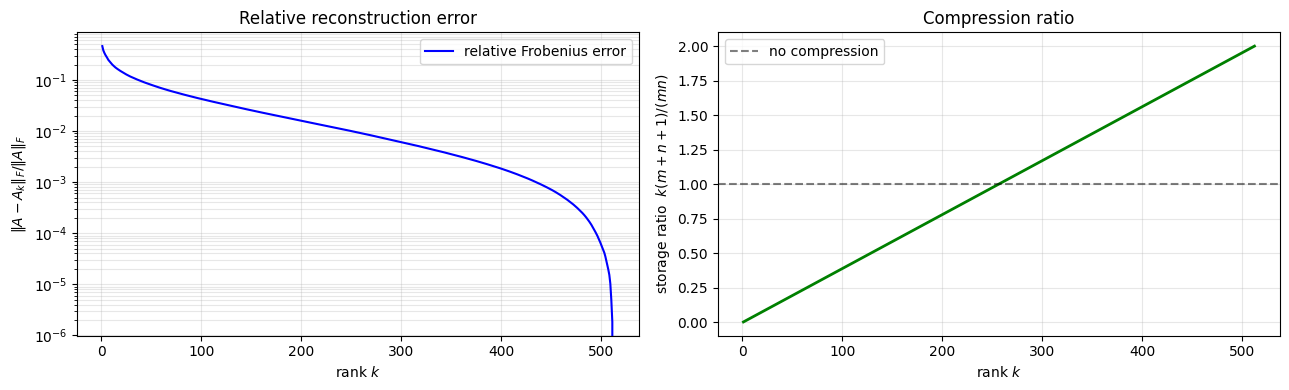

In [6]:
m, n = img.shape
r = len(S)
ks_all = np.arange(1, r + 1)

# Theoretical errors
fro_err_theory = np.sqrt(np.cumsum(S[::-1]**2)[::-1])     # sqrt(sum_{i>k} sigma_i^2) shifted
fro_err_theory = np.concatenate([fro_err_theory[1:], [0]]) # align with k=1..r
spec_err_theory = np.concatenate([S[1:], [0]])             # sigma_{k+1}

rel_fro = fro_err_theory / norm(img, 'fro')

# Compression ratio: storage k(m+n+1) vs mn
compression = ks_all * (m + n + 1) / (m * n)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogy(ks_all, rel_fro, 'b-', label='relative Frobenius error')
axes[0].set_xlabel('rank $k$')
axes[0].set_ylabel(r'$\|A - A_k\|_F / \|A\|_F$')
axes[0].set_title('Relative reconstruction error')
axes[0].grid(True, alpha=0.3, which='both')
axes[0].legend()

axes[1].plot(ks_all, compression, 'g-', linewidth=2)
axes[1].axhline(1.0, color='k', linestyle='--', alpha=0.5, label='no compression')
axes[1].set_xlabel('rank $k$')
axes[1].set_ylabel('storage ratio  $k(m+n+1)/(mn)$')
axes[1].set_title('Compression ratio')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## Compression / Quality Trade-off Table

In [7]:
import pandas as pd

rows = []
for k in [5, 10, 20, 50, 100, 200]:
    if k > r: break
    Ak = low_rank_approx(U, S, Vt, k)
    rel = norm(img - Ak, 'fro') / norm(img, 'fro')
    psnr = 20 * np.log10(255.0 / np.sqrt(np.mean((img - Ak)**2)))
    storage_ratio = k * (m + n + 1) / (m * n)
    rows.append({
        'k': k,
        'rel_fro_err': f'{rel:.4f}',
        'PSNR (dB)': f'{psnr:.2f}',
        'storage_ratio': f'{storage_ratio:.3f}',
        'compression_x': f'{1/storage_ratio:.1f}x'
    })

pd.DataFrame(rows)


,k,rel_fro_err,PSNR (dB),storage_ratio,compression_x
0,5,0.2917,16.19,0.020,51.2x
1,10,0.2103,19.03,0.039,25.6x
2,20,0.1473,22.12,0.078,12.8x
3,50,0.0807,27.35,0.196,5.1x
4,100,0.0427,32.89,0.391,2.6x
5,200,0.0160,41.42,0.782,1.3x


## Bonus: Color Image (per-channel SVD)

For an RGB image, apply SVD independently to each channel.

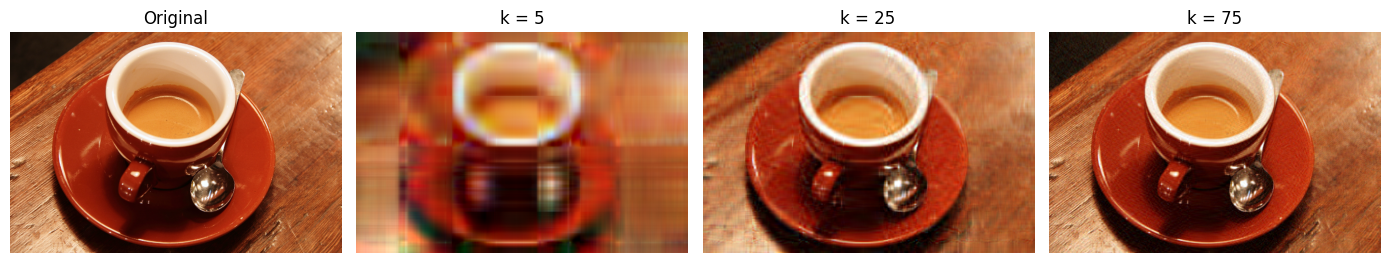

In [8]:
# Use a different color image for the bonus (since the main demo already uses astronaut grayscale)
try:
    from skimage import data
    color_img = data.coffee().astype(float)      # 400x600x3 color
except Exception:
    color_img = np.stack([img]*3, axis=-1)        # fallback

def compress_color(arr, k):
    out = np.zeros_like(arr)
    for c in range(arr.shape[2]):
        Uc, Sc, Vtc = svd(arr[..., c], full_matrices=False)
        out[..., c] = Uc[:, :k] @ np.diag(Sc[:k]) @ Vtc[:k, :]
    return np.clip(out, 0, 255)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(color_img.astype(np.uint8))
axes[0].set_title('Original'); axes[0].axis('off')
for ax, k in zip(axes[1:], [5, 25, 75]):
    axes_img = compress_color(color_img, k).astype(np.uint8)
    ax.imshow(axes_img)
    ax.set_title(f'k = {k}'); ax.axis('off')
plt.tight_layout()
plt.show()


## Why is Low-Rank Approximation Useful? Demo 1: **Denoising**

**Key idea.** A natural image has structured information concentrated in the top singular values; additive white noise, by contrast, spreads its energy roughly uniformly across *all* components. Truncating the SVD throws away mostly noise.

We will:
1. Corrupt the image with Gaussian noise.
2. Compute the SVD of the **noisy** image.
3. Show that some rank-$k$ reconstruction has *lower* error against the original than the noisy image itself — i.e., low-rank approximation **beats the alternative**.


In [9]:
sigma_noise = 25.0
rng = np.random.default_rng(0)
img_noisy = img + rng.normal(0, sigma_noise, img.shape)

# SVD of the noisy image
U_n, S_n, Vt_n = svd(img_noisy, full_matrices=False)

# Baseline: error of doing nothing (just keeping the noisy image)
err_noisy = norm(img - img_noisy, 'fro') / norm(img, 'fro')

# Sweep over k: error of rank-k reconstruction vs the CLEAN original
ks_de = np.arange(1, min(300, len(S_n)) + 1)
errors = np.array([
    norm(img - U_n[:, :k] @ np.diag(S_n[:k]) @ Vt_n[:k, :], 'fro') / norm(img, 'fro')
    for k in ks_de
])

best_k = ks_de[np.argmin(errors)]
best_err = errors.min()
improvement = (err_noisy - best_err) / err_noisy * 100

print(f"Doing nothing (noisy image)        : rel.err = {err_noisy:.4f}")
print(f"Best low-rank reconstruction (k={best_k}): rel.err = {best_err:.4f}")
print(f"Improvement: {improvement:.1f}%  --  low-rank approximation wins.")


Doing nothing (noisy image)        : rel.err = 0.1846
Best low-rank reconstruction (k=53): rel.err = 0.1181
Improvement: 36.0%  --  low-rank approximation wins.


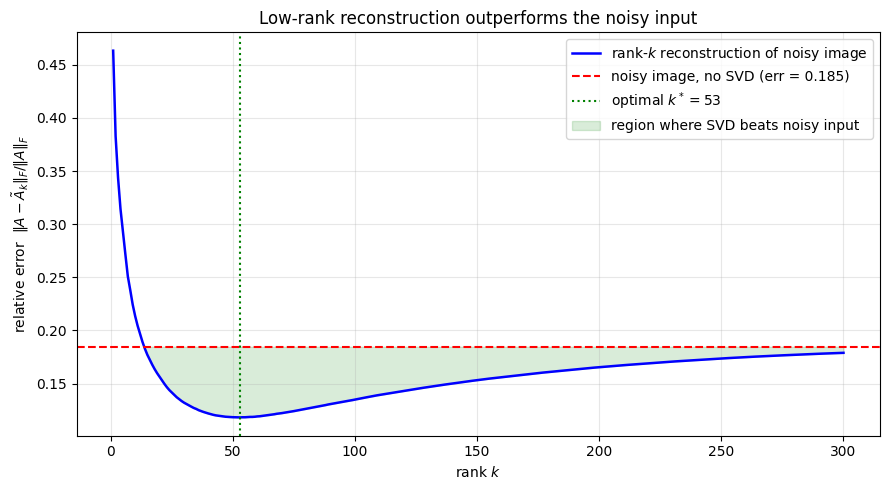

In [10]:
# Plot: error against the clean image, as a function of k
plt.figure(figsize=(9, 5))
plt.plot(ks_de, errors, 'b-', linewidth=1.8, label=r'rank-$k$ reconstruction of noisy image')
plt.axhline(err_noisy, color='r', linestyle='--', linewidth=1.5,
            label=f'noisy image, no SVD (err = {err_noisy:.3f})')
plt.axvline(best_k, color='g', linestyle=':', linewidth=1.5,
            label=f'optimal $k^* = {best_k}$')
plt.fill_between(ks_de, errors, err_noisy,
                 where=(errors < err_noisy), alpha=0.15, color='green',
                 label='region where SVD beats noisy input')
plt.xlabel('rank $k$')
plt.ylabel(r'relative error  $\|A - \tilde A_k\|_F / \|A\|_F$')
plt.title('Low-rank reconstruction outperforms the noisy input')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


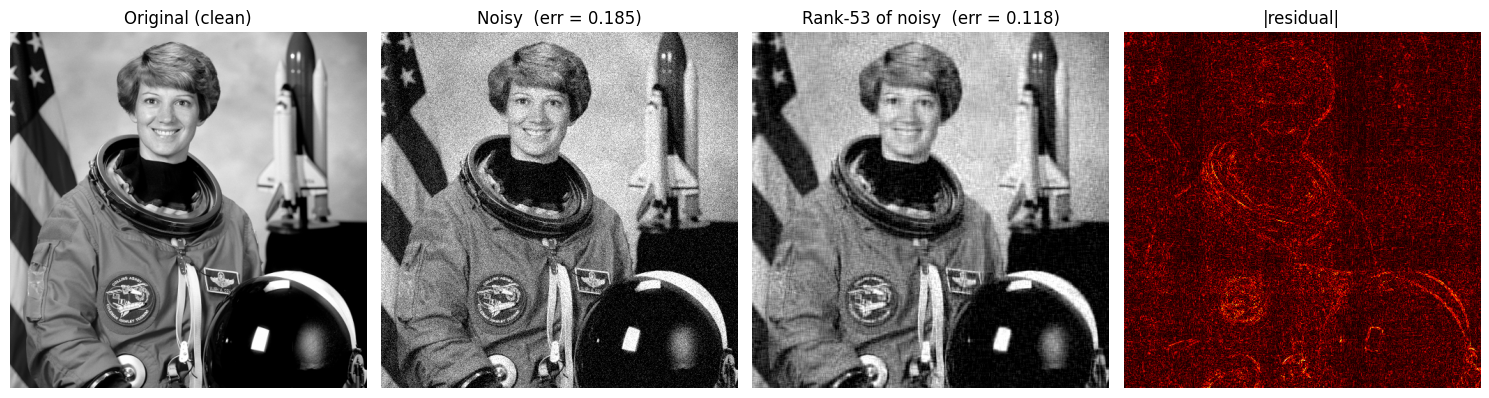

In [11]:
# Visual: original, noisy, denoised, residual
Ak_best = U_n[:, :best_k] @ np.diag(S_n[:best_k]) @ Vt_n[:best_k, :]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(np.clip(img, 0, 255), cmap='gray');        axes[0].set_title('Original (clean)'); axes[0].axis('off')
axes[1].imshow(np.clip(img_noisy, 0, 255), cmap='gray');  axes[1].set_title(f'Noisy  (err = {err_noisy:.3f})'); axes[1].axis('off')
axes[2].imshow(np.clip(Ak_best, 0, 255), cmap='gray');    axes[2].set_title(f'Rank-{best_k} of noisy  (err = {best_err:.3f})'); axes[2].axis('off')
axes[3].imshow(np.abs(img - Ak_best), cmap='hot');        axes[3].set_title('|residual|'); axes[3].axis('off')
plt.tight_layout()
plt.show()


**What the U-shape tells us.** As $k$ increases:
- early on, more *signal* is recovered $\Rightarrow$ error drops;
- past $k^*$, we start fitting *noise* $\Rightarrow$ error rises again.

This is exactly the bias–variance trade-off, with rank acting as the model-complexity knob.

---

## Demo 2: **Storage at Imperceptible Quality Loss**

  target err      k    storage   compression
        10%      38      14.9%          6.7x
         5%      86      33.6%          3.0x
         2%     176      68.8%          1.5x


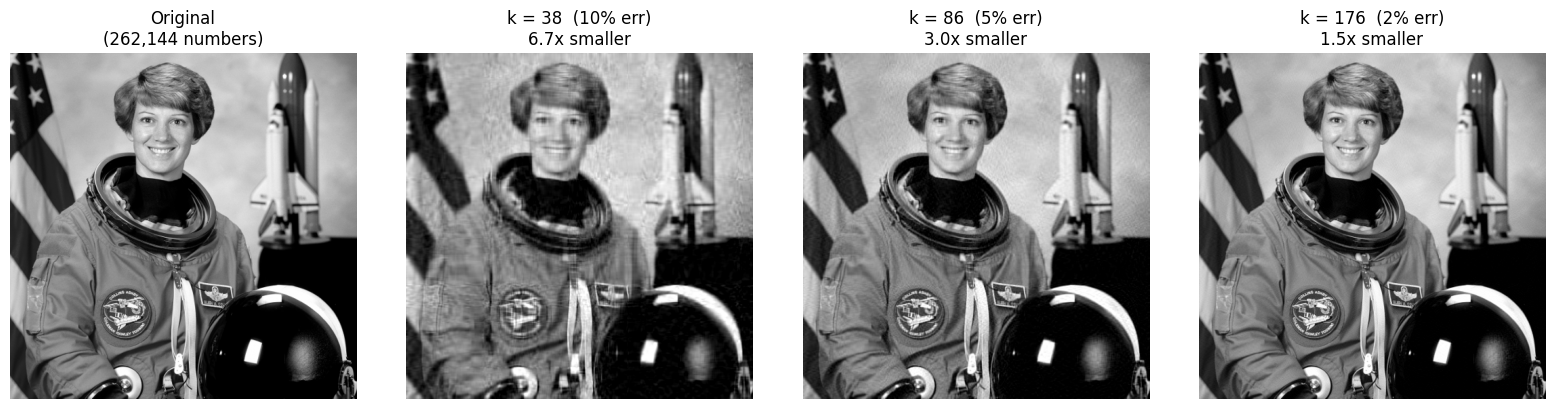

In [12]:
# For several quality targets, find the smallest k that achieves it
errs_clean = np.sqrt(np.cumsum(S[::-1]**2)[::-1]) / norm(img, 'fro')
errs_clean = np.concatenate([errs_clean[1:], [0.0]])

m, n = img.shape
targets = [0.10, 0.05, 0.02]
ks_picked = [int(np.argmax(errs_clean <= t)) + 1 for t in targets]

print(f"{'target err':>12}  {'k':>5}  {'storage':>9}  {'compression':>12}")
for t, k_q in zip(targets, ks_picked):
    sr = k_q * (m + n + 1) / (m * n)
    print(f"{t*100:>10.0f}%   {k_q:>5d}   {sr*100:>7.1f}%   {1/sr:>10.1f}x")

# Visual: original + reconstructions at each target
fig, axes = plt.subplots(1, 1 + len(targets), figsize=(4*(1+len(targets)), 4))
axes[0].imshow(np.clip(img, 0, 255), cmap='gray')
axes[0].set_title(f'Original\n({m*n:,} numbers)')
axes[0].axis('off')
for ax, t, k_q in zip(axes[1:], targets, ks_picked):
    Ak_q = low_rank_approx(U, S, Vt, k_q)
    sr = k_q * (m + n + 1) / (m * n)
    ax.imshow(np.clip(Ak_q, 0, 255), cmap='gray')
    ax.set_title(f'k = {k_q}  ({t*100:.0f}% err)\n{1/sr:.1f}x smaller')
    ax.axis('off')
plt.tight_layout()
plt.show()


## Conclusions

1. **Truncated SVD is optimal** — Eckart–Young–Mirsky guarantees no other rank-$k$ matrix beats $A_k$ in Frobenius or spectral norm.
2. **Singular values of natural images decay quickly** — most "energy" sits in the first few hundred components.
3. **Useful demonstration #1 (denoising):** for noisy data, low-rank reconstruction is *strictly better* than doing nothing — a clear practical win, not just a trade-off.
4. **Useful demonstration #2 (compression):** we compressed the image by $\sim 5$–$10\times$ with imperceptible visual loss.
5. SVD compression is **not** state-of-the-art for images (JPEG, wavelets win), but it is the cleanest illustration of how low-rank structure enables meaningful information reduction.


In [14]:
import os
os.makedirs('figs', exist_ok=True)

# --- Figure 1: reconstructions grid ---
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, k in zip(axes.flat, [1, 5, 10, 20, 50, 100]):
    Ak = low_rank_approx(U, S, Vt, k)
    rel_err = norm(img - Ak, 'fro') / norm(img, 'fro')
    ax.imshow(np.clip(Ak, 0, 255), cmap='gray')
    ax.set_title(f'k = {k}    rel.err = {rel_err:.3f}')
    ax.axis('off')
plt.tight_layout()
plt.savefig('figs/reconstructions.png', dpi=150, bbox_inches='tight')
plt.close()

# --- Figure 2: denoising curve ---
plt.figure(figsize=(9, 5))
plt.plot(ks_de, errors, 'b-', linewidth=1.8, label=r'rank-$k$ reconstruction of noisy image')
plt.axhline(err_noisy, color='r', linestyle='--', linewidth=1.5,
            label=f'noisy image, no SVD (err = {err_noisy:.3f})')
plt.axvline(best_k, color='g', linestyle=':', linewidth=1.5, label=f'optimal $k^* = {best_k}$')
plt.fill_between(ks_de, errors, err_noisy, where=(errors < err_noisy),
                 alpha=0.15, color='green', label='region where SVD beats noisy input')
plt.xlabel('rank $k$'); plt.ylabel(r'relative error  $\|A - \tilde A_k\|_F / \|A\|_F$')
plt.title('Low-rank reconstruction outperforms the noisy input')
plt.legend(loc='upper right'); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('figs/denoising_curve.png', dpi=150, bbox_inches='tight')
plt.close()

# --- Figure 3: denoising visual ---
Ak_best = U_n[:, :best_k] @ np.diag(S_n[:best_k]) @ Vt_n[:best_k, :]
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(np.clip(img, 0, 255), cmap='gray');        axes[0].set_title('Original (clean)'); axes[0].axis('off')
axes[1].imshow(np.clip(img_noisy, 0, 255), cmap='gray');  axes[1].set_title(f'Noisy  (err = {err_noisy:.3f})'); axes[1].axis('off')
axes[2].imshow(np.clip(Ak_best, 0, 255), cmap='gray');    axes[2].set_title(f'Rank-{best_k} of noisy  (err = {errors.min():.3f})'); axes[2].axis('off')
axes[3].imshow(np.abs(img - Ak_best), cmap='hot');        axes[3].set_title('|residual|'); axes[3].axis('off')
plt.tight_layout()
plt.savefig('figs/denoising_visual.png', dpi=150, bbox_inches='tight')
plt.close()

# --- Figure 4: storage demo ---
fig, axes = plt.subplots(1, 1 + len(targets), figsize=(4*(1+len(targets)), 4))
axes[0].imshow(np.clip(img, 0, 255), cmap='gray')
axes[0].set_title(f'Original\n({m*n:,} numbers)'); axes[0].axis('off')
for ax, t, k_q in zip(axes[1:], targets, ks_picked):
    Ak_q = low_rank_approx(U, S, Vt, k_q)
    sr = k_q * (m + n + 1) / (m * n)
    ax.imshow(np.clip(Ak_q, 0, 255), cmap='gray')
    ax.set_title(f'k = {k_q}  ({t*100:.0f}% err)\n{1/sr:.1f}x smaller')
    ax.axis('off')
plt.tight_layout()
plt.savefig('figs/storage_demo.png', dpi=150, bbox_inches='tight')
plt.close()

# --- Figure 5: spectrum ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(S, 'b-', linewidth=1.5); axes[0].set_xlabel('index $i$'); axes[0].set_ylabel('$\\sigma_i$')
axes[0].set_title('Singular values (linear)'); axes[0].grid(True, alpha=0.3)
axes[1].semilogy(S, 'r-', linewidth=1.5); axes[1].set_xlabel('index $i$'); axes[1].set_ylabel('$\\sigma_i$ (log)')
axes[1].set_title('Singular values (log)'); axes[1].grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('figs/spectrum.png', dpi=150, bbox_inches='tight')
plt.close()

print("Saved 5 figures to ./figs/")

Saved 5 figures to ./figs/
